## 1. Imports & Circuit Values

Circuit parameters used to generate the fake data:
- **R** = 1100 Ω
- **L** = 10.46 mH
- **V_max** = 1 V (peak input voltage)
- **Frequency sweep**: 200 Hz – 200 000 Hz

Known capacitances for comparison after back-calculation:
| Label | C (µF) | Expected f₀ (Hz) |
|---|---|---|
| C1uF | 1.0 | 1299.5 |
| C2_2uF | 2.2 | 876.1 |
| C4_7uF | 4.7 | 599.4 |
| C10uF | 10.0 | 410.9 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Circuit values
R     = 1100      # ohms
L     = 10.46e-3     # henries
V_max = 1.0       # volts (peak input)

# Known capacitances for comparison (label -> farads)
KNOWN_C = {
    "C5.7pF":   5.7e-12,
    "C6.3pF": 6.3e-12,
    "C8.2pF": 8.2e-12,
    "C8.5pF":  8.5e-12,
    "C11.9pF": 11.9e-12,
    "C32.6pF": 32.6e-12,
    "C69.1nF": 69.1e-9,
    "C102.1pF": 102.1e-12,
    "C481pF": 481e-12,
}

## 2. Load Data Files

Scans  for all  files.  
In the real project this folder will contain several thousand files — the glob approach handles that automatically.

In [2]:
DATA_DIR = Path("real_data_10")

files = sorted(DATA_DIR.glob("rlc_sweep_*.csv"))
print(f"Found {len(files)} files:")
for f in files:
    print(" ", f.name)

# Load all into a dict keyed by file stem
data = {f.stem: pd.read_csv(f) for f in files}

Found 10 files:
  rlc_sweep_10_C102.1pF.csv
  rlc_sweep_10_C11.9pF.csv
  rlc_sweep_10_C32.6pF.csv
  rlc_sweep_10_C481pF.csv
  rlc_sweep_10_C5.7pF.csv
  rlc_sweep_10_C6.3pF.csv
  rlc_sweep_10_C69.1nF.csv
  rlc_sweep_10_C8.2pF.csv
  rlc_sweep_10_C8.5pF.csv
  rlc_sweep_10_Ctest.csv


## 3. Plot All Files

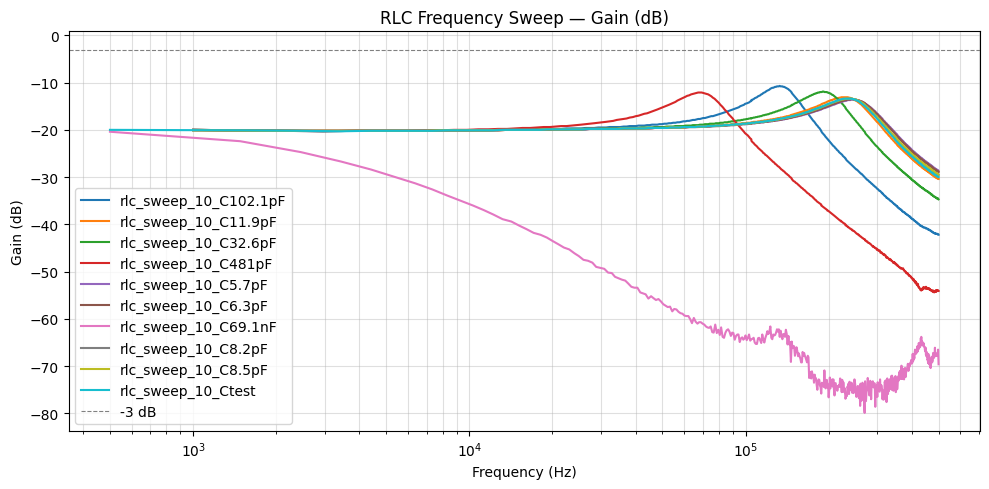

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, df in data.items():
    ax.semilogx(df["frequency_hz"], df["gain_db"], label=name)

ax.axhline(-3, color="gray", linestyle="--", linewidth=0.8, label="-3 dB")
ax.set_title("RLC Frequency Sweep — Gain (dB)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Gain (dB)")
ax.legend()
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Find Peak Frequency for Each File

The frequency at which gain is maximum is the resonant frequency f₀.

In [4]:
peaks = {}
for name, df in data.items():
    idx = df["gain_db"].idxmax()
    peaks[name] = df.loc[idx, "frequency_hz"]

peak_df = pd.DataFrame.from_dict(peaks, orient="index", columns=["peak_freq_hz"])
peak_df.index.name = "file"
peak_df

,peak_freq_hz
file,
rlc_sweep_10_C102.1pF,133000.0
rlc_sweep_10_C11.9pF,222000.0
rlc_sweep_10_C32.6pF,190000.0
rlc_sweep_10_C481pF,67400.0
rlc_sweep_10_C5.7pF,241000.0
rlc_sweep_10_C6.3pF,240000.0
rlc_sweep_10_C69.1nF,500.0
rlc_sweep_10_C8.2pF,231000.0
rlc_sweep_10_C8.5pF,230000.0


## 5. Back-Calculate Capacitance

Using the resonant frequency formula:  
**f₀ = 1 / (2π √(LC))**  
→ **C = 1 / (L · (2π f₀)²)**

In [5]:
rows = []
for name, f0 in peaks.items():
    C_calc = 1 / (L * (2 * np.pi * f0) ** 2)
    label  = name.replace("rlc_sweep_10_", "")
    C_known = KNOWN_C.get(label, None)
    rows.append({
        "file":          name,
        "peak_freq_hz":  f0,
        "C_calculated_pF": round(C_calc * 1e12, 4),
        "C_known_pF":    round(C_known * 1e12, 4) if C_known else None,
        "error_%":       round(abs(C_calc - C_known) / C_known * 100, 2) if C_known else None,
    })

pd.DataFrame(rows)

,file,peak_freq_hz,C_calculated_pF,C_known_pF,error_%
0,rlc_sweep_10_C102.1pF,133000.0,1.369006e+02,102.1,34.08
1,rlc_sweep_10_C11.9pF,222000.0,4.913630e+01,11.9,312.91
2,rlc_sweep_10_C32.6pF,190000.0,6.708130e+01,32.6,105.77
3,rlc_sweep_10_C481pF,67400.0,5.330756e+02,481.0,10.83
4,rlc_sweep_10_C5.7pF,241000.0,4.169410e+01,5.7,631.48
5,rlc_sweep_10_C6.3pF,240000.0,4.204230e+01,6.3,567.34
6,rlc_sweep_10_C69.1nF,500.0,9.686538e+06,69100.0,13918.14
7,rlc_sweep_10_C8.2pF,231000.0,4.538210e+01,8.2,453.44
8,rlc_sweep_10_C8.5pF,230000.0,4.577760e+01,8.5,438.56
9,rlc_sweep_10_Ctest,226000.0,4.741240e+01,NaN,NaN


## 6. Plotting Calibration Curve (results for 10x probe)

Using the formula:  
**1 / w0^2 = L * C_{actual} + L * C_{parasitic}**

In [6]:
rows_corrected = [ rows[i] for i in range(9) if i != 6]
print(rows_corrected)

[{'file': 'rlc_sweep_10_C102.1pF', 'peak_freq_hz': 133000.0, 'C_calculated_pF': 136.9006, 'C_known_pF': 102.1, 'error_%': 34.08}, {'file': 'rlc_sweep_10_C11.9pF', 'peak_freq_hz': 222000.0, 'C_calculated_pF': 49.1363, 'C_known_pF': 11.9, 'error_%': 312.91}, {'file': 'rlc_sweep_10_C32.6pF', 'peak_freq_hz': 190000.0, 'C_calculated_pF': 67.0813, 'C_known_pF': 32.6, 'error_%': 105.77}, {'file': 'rlc_sweep_10_C481pF', 'peak_freq_hz': 67400.0, 'C_calculated_pF': 533.0756, 'C_known_pF': 481.0, 'error_%': 10.83}, {'file': 'rlc_sweep_10_C5.7pF', 'peak_freq_hz': 241000.0, 'C_calculated_pF': 41.6941, 'C_known_pF': 5.7, 'error_%': 631.48}, {'file': 'rlc_sweep_10_C6.3pF', 'peak_freq_hz': 240000.0, 'C_calculated_pF': 42.0423, 'C_known_pF': 6.3, 'error_%': 567.34}, {'file': 'rlc_sweep_10_C8.2pF', 'peak_freq_hz': 231000.0, 'C_calculated_pF': 45.3821, 'C_known_pF': 8.2, 'error_%': 453.44}, {'file': 'rlc_sweep_10_C8.5pF', 'peak_freq_hz': 230000.0, 'C_calculated_pF': 45.7776, 'C_known_pF': 8.5, 'error_%':

[1.08033962e-02 3.70341310e-13] variances = [2.64525636e-09 8.04162727e-29]
Parastic capacitance = (34.3 $\pm$ 0.1) pF


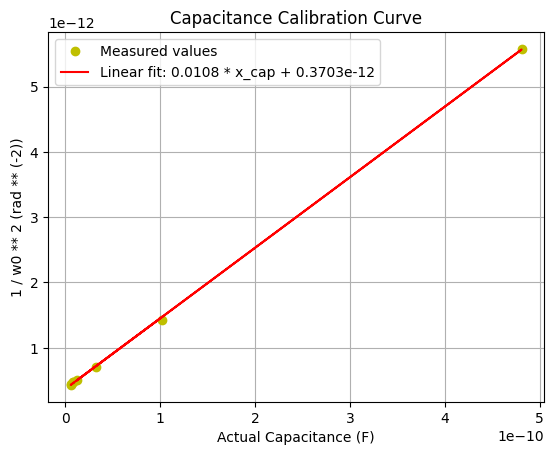

In [7]:
x_cap = np.array([ elt.get("C_known_pF") for elt in rows_corrected ]) * 1e-12
y_freq = np.array([ elt.get("peak_freq_hz") for elt in rows_corrected ])

#print(x_cap)
y_val = 1 / ((2*np.pi*y_freq) ** 2)

fit_para, cov = np.polyfit(x_cap, y_val, 1 , cov = True)
a, b = fit_para
print(fit_para, f"variances = {np.diag(cov)}")
print(f"Parastic capacitance = ({round((b / a)* 10 ** 12, 1)} $\pm$ {np.max([round(np.sqrt(np.diag(cov)[1]), 1), 0.1])}) pF")

plt.plot(x_cap, y_val, 'yo', label = "Measured values")
plt.plot(x_cap, a*x_cap+b, '-r', label = f"Linear fit: {round(a,4)} * x_cap + {round(b*1e12,4)}e-12")
plt.xlabel("Actual Capacitance (F)")
plt.ylabel("1 / w0 ** 2 (rad ** (-2))")
plt.title("Capacitance Calibration Curve")
plt.legend()
plt.grid()
plt.show()

## 6. Calculating Test Capacitance

Using the Calibration data

In [8]:
test_resonance = rows_corrected[-1].get('peak_freq_hz')

def cap_calc(f):
    return ( 1 / (2*np.pi*f) ** 2 - b) / a

print(cap_calc(test_resonance) * 10 ** 12, "pF")

10.042421707806877 pF
